# Analysis and creating figures
This notebook contains the code for visualising findings.


In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import calendar
import plotly.express as px
import numpy as np
from math import ceil
import numpy as np
from scipy.stats import chi2_contingency


## Data Loading

Load the data.

In [11]:
df = pd.read_csv('../tweede_kamer_data.csv', index_col=0)
df.head()

,title,year,ai_related,company_hits,body,matched_keywords_all,type
0,Investeren in Perspectief (Beleidsnota 2018),2018,yes,"['adyen', 'google', 'x']",Ook biedt de agenda kansen aan het bedrijfslev...,"['adyen', 'google', 'x', 'kunstmatige intellig...",beleidsnota
1,Nota Defensie Industrie Strategie,2018,yes,[],Nederland wil zelf aan militaire kennisontwikk...,"['ai', 'artificiële intelligentie', 'drones', ...",beleidsnota
2,Nationale Strategie Digitaal Erfgoed 2021-2024,2021,yes,['google'],Zo wordt in de vernieuwde strategie nu ook de ...,"['google', 'ai', 'algoritmes', 'artificiële in...",beleidsnota
3,Beslisnota's bij de Kamerbrief over toekomstig...,2021,yes,['x'],25 januari\n37 9-2-2023 Nota-StasGB-Memo box 3...,"['x', 'ai']",beleidsnota
4,Beslisnota bij Kamerbrief over aanpak belastin...,2021,yes,['x'],Dit betreft de nota’s in de onderstaande tabel...,"['x', 'ai']",beleidsnota


## Descriptive Statistics

Basic counts and coverage checks: outlets in the dataset, articles per outlet, year range, and duplicate detection.

In [14]:
# ensure year is integer
df['year'] = df['year'].astype(int)

# A) Long (tidy) table: one row per (program, year)
counts_long = (
    df.groupby(['type', 'year'])
      .size()
      .rename('n')
      .reset_index()
      .sort_values(['type', 'year'])
)
counts_long
ranges = df.groupby('type')['year'].agg(year_min='min', year_max='max')

In [15]:
counts_long.to_excel('counts_programs.xlsx')

In [16]:
counts_long.head()

,type,year,n
0,beleidsnota,2018,2
1,beleidsnota,2021,3
2,beleidsnota,2022,14
3,beleidsnota,2023,100
4,beleidsnota,2024,105


## Article Volume Over Time

How many AI-related articles were published per outlet per year? The combined plot gives an overview; the faceted version allows per-outlet comparison.

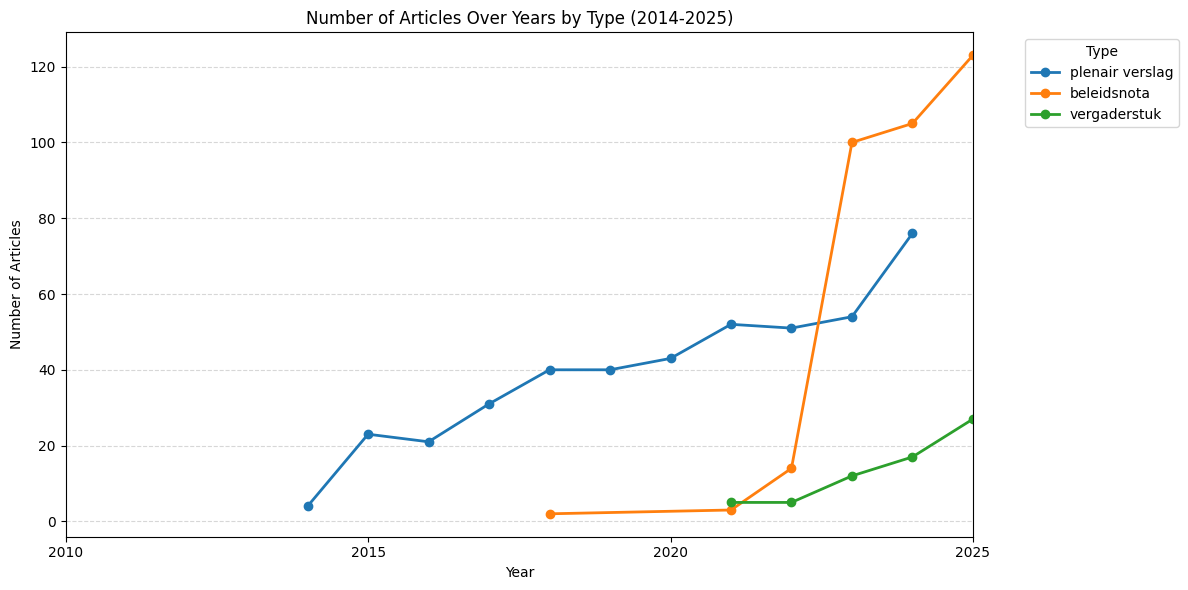

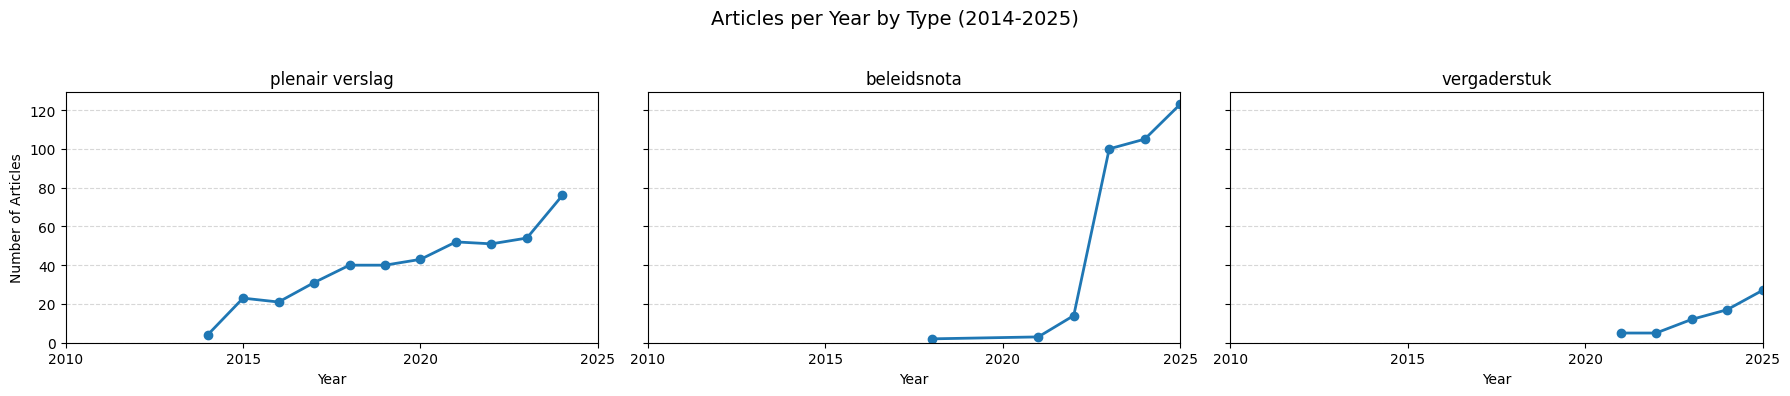

In [17]:
# ===== Config (tweak as needed) =====
TOP_OUTLETS   = None   # e.g. 6 to only show top-6 by volume; None = all
START_YEAR    = None   # e.g. 2000 to force a fixed start
END_YEAR      = None   # e.g. 2024 to force a fixed end
FIVE_YEAR_TICKS = True

# Prep
d = df[['type','year']].dropna().copy()
d['year'] = d['year'].astype(int)

# Count the number of articles per program per year
articles_per_year = (
    d.groupby(['type','year'])
     .size()
     .reset_index(name='count')
     .sort_values(['type','year'])
)

# Which types (optionally top-N by total volume)?
totals = articles_per_year.groupby('type')['count'].sum().sort_values(ascending=False)
types = totals.index.tolist() if TOP_OUTLETS is None else totals.head(TOP_OUTLETS).index.tolist()

# Year range (auto unless overridden)
yr_min = int(articles_per_year['year'].min()) if START_YEAR is None else int(START_YEAR)
yr_max = int(articles_per_year['year'].max()) if END_YEAR   is None else int(END_YEAR)

def five_year_ticks(start, end):
    start5 = (start // 5) * 5
    step   = 5 if (end - start) >= 5 else 1
    return np.arange(start5, end + 1, step)

# =========================
# 1) Combined plot (all outlets)
# =========================
plt.figure(figsize=(12, 6))
for type in types:
    od = articles_per_year[articles_per_year['type'] == type]
    plt.plot(od['year'], od['count'], marker='o', linewidth=2, label=type)

plt.xlim(yr_min, yr_max)
if FIVE_YEAR_TICKS:
    plt.xticks(five_year_ticks(yr_min, yr_max))
plt.xlabel('Year')
plt.ylabel('Number of Articles')
plt.title(f'Number of Articles Over Years by Type ({yr_min}-{yr_max})')
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# =========================
# 2) Facet: one graph per type
# =========================
n = len(types)
ncols = 3 if n >= 3 else n
nrows = ceil(n / ncols) if n else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharey=True)
axes = np.atleast_1d(axes).flatten()

# consistent y-limit for comparability
global_ymax = articles_per_year['count'].max()

for ax, type in zip(axes, types):
    od = articles_per_year[articles_per_year['type'] == type].copy()
    ax.plot(od['year'], od['count'], marker='o', linewidth=2)

    ax.set_xlim(yr_min, yr_max)
    if FIVE_YEAR_TICKS:
        ax.set_xticks(five_year_ticks(yr_min, yr_max))
    ax.set_ylim(0, global_ymax * 1.05)

    ax.set_title(type)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.set_xlabel('Year')

# tidy layout
for j in range(len(types), len(axes)):
    axes[j].axis('off')
axes[0].set_ylabel('Number of Articles')

fig.suptitle(f'Articles per Year by Type ({yr_min}-{yr_max})', y=0.98, fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [18]:
counts_wide = pd.crosstab(df['type'], df['year'])
# with totals:
# counts_wide = pd.crosstab(df['news_brand'], df['year'], margins=True, margins_name='Total')
counts_wide


year,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
type,,,,,,,,,,,,
beleidsnota,0,0,0,0,2,0,0,3,14,100,105,123
plenair verslag,4,23,21,31,40,40,43,52,51,54,76,0
vergaderstuk,0,0,0,0,0,0,0,5,5,12,17,27


In [20]:
# #proportion of migration articles vs total
# counts = pd.read_excel('../data/articles_per_year_by_program.xlsx')
# counts